# HLDA lambda threshold analysis

Find best thresholds for 41bb, |41bb|, and log(bb/bb_WT).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from common.utils import collect_df
from common.hlda_utils import load_lambda_grid
from common.consts import res_colors
from common.plot_utils import scatter_with_labels
from paper.style_utils import set_paper_style

set_paper_style()

%config InlineBackend.figure_format = 'retina'


In [2]:
data_dir = repo_root / 'data'
mfpt_path = data_dir / 'mfpt-pace=25000-new-ref.pkl'
lambda_cache = data_dir / 'hlda_lambda_grid.pkl'

mfpt_all = pd.read_pickle(mfpt_path)
lambda_grid = load_lambda_grid(
    cache_path=lambda_cache,
    base_dir=data_dir / "traj",
    force=False,
)


In [3]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap='YlOrRd'):
    P = df.pivot(index='tF', columns='tU', values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='flat'
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f'{val:.2f}', ha='center', va='center', fontsize=6)

    ax.set_xlabel('tU')
    ax.set_ylabel('tF')
    ax.set_title(title, fontsize=9)
    return im


In [4]:
mfpt_thresholds = sorted({float(k) for v in mfpt_all.values() for k in v.keys()})
unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())
skip_short = set()

metrics = [
    ('lambda', 'Lambda'),
    # ('delta_lambda', 'Delta lambda (mut - WT)'),
    ('abs_delta_lambda', 'Abs delta lambda'),
    # ('rel_delta_lambda', 'Delta lambda / lambda_WT'),
    # ('log_lambda_ratio', 'log(lambda / lambda_WT)'),
]

best_rows = []
best_cache = {}
heatmap_cache = {}


In [5]:
for metric_key, metric_label in metrics:
    best = {'score': -np.inf}
    heatmap_rows = []
    for thr in mfpt_thresholds:
        rows = []
        for tF in unique_tf:
            for tU in unique_tu:
                if tU <= tF:
                    continue
                sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
                if sub_lam.empty:
                    continue
                df_thr = collect_df(
                    mfpt_all,
                    mfpt_threshold=float(thr),
                    tF=float(tF),
                    tU=float(tU),
                    lambda_df=sub_lam,
                    skip_short=skip_short,
                    quiet=True,
                )
                wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
                df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
                wt_lambda = float(df_thr.loc['WT', 'lambda'])
                df_thr['delta_lambda'] = df_thr['lambda'] - wt_lambda
                df_thr['abs_delta_lambda'] = df_thr['delta_lambda'].abs()
                df_thr['rel_delta_lambda'] = df_thr['delta_lambda'] / wt_lambda
                df_thr['log_lambda_ratio'] = np.log(df_thr['lambda'] / wt_lambda)

                x = df_thr[metric_key]
                y = df_thr['log_mfpt_ratio']
                rho = x.corr(y, method='spearman')
                pear = x.corr(y, method='pearson')
                score = np.nanmean([abs(rho)])
                rows.append({
                    'tF': float(tF),
                    'tU': float(tU),
                    'val': abs(rho) if pd.notna(rho) else np.nan,
                    'pear': abs(pear) if pd.notna(pear) else np.nan,
                })
                if score > best['score']:
                    best = {
                        'metric': metric_key,
                        'metric_label': metric_label,
                        'thr': float(thr),
                        'tF': float(tF),
                        'tU': float(tU),
                        'rho': float(rho),
                        'pear': float(pear),
                        'score': float(score),
                    }
                    best_cache[metric_key] = df_thr
        heatmap_rows.append({'thr': float(thr), 'rows': rows})
    best_rows.append(best)
    heatmap_cache[metric_key] = heatmap_rows

best_df = pd.DataFrame(best_rows)
best_df


,metric,metric_label,thr,tF,tU,rho,pear,score
0,lambda,Lambda,0.28,0.29,0.52,-0.580917,-0.428944,0.580917
1,abs_delta_lambda,Abs delta lambda,0.48,0.29,0.74,-0.454207,-0.427614,0.454207


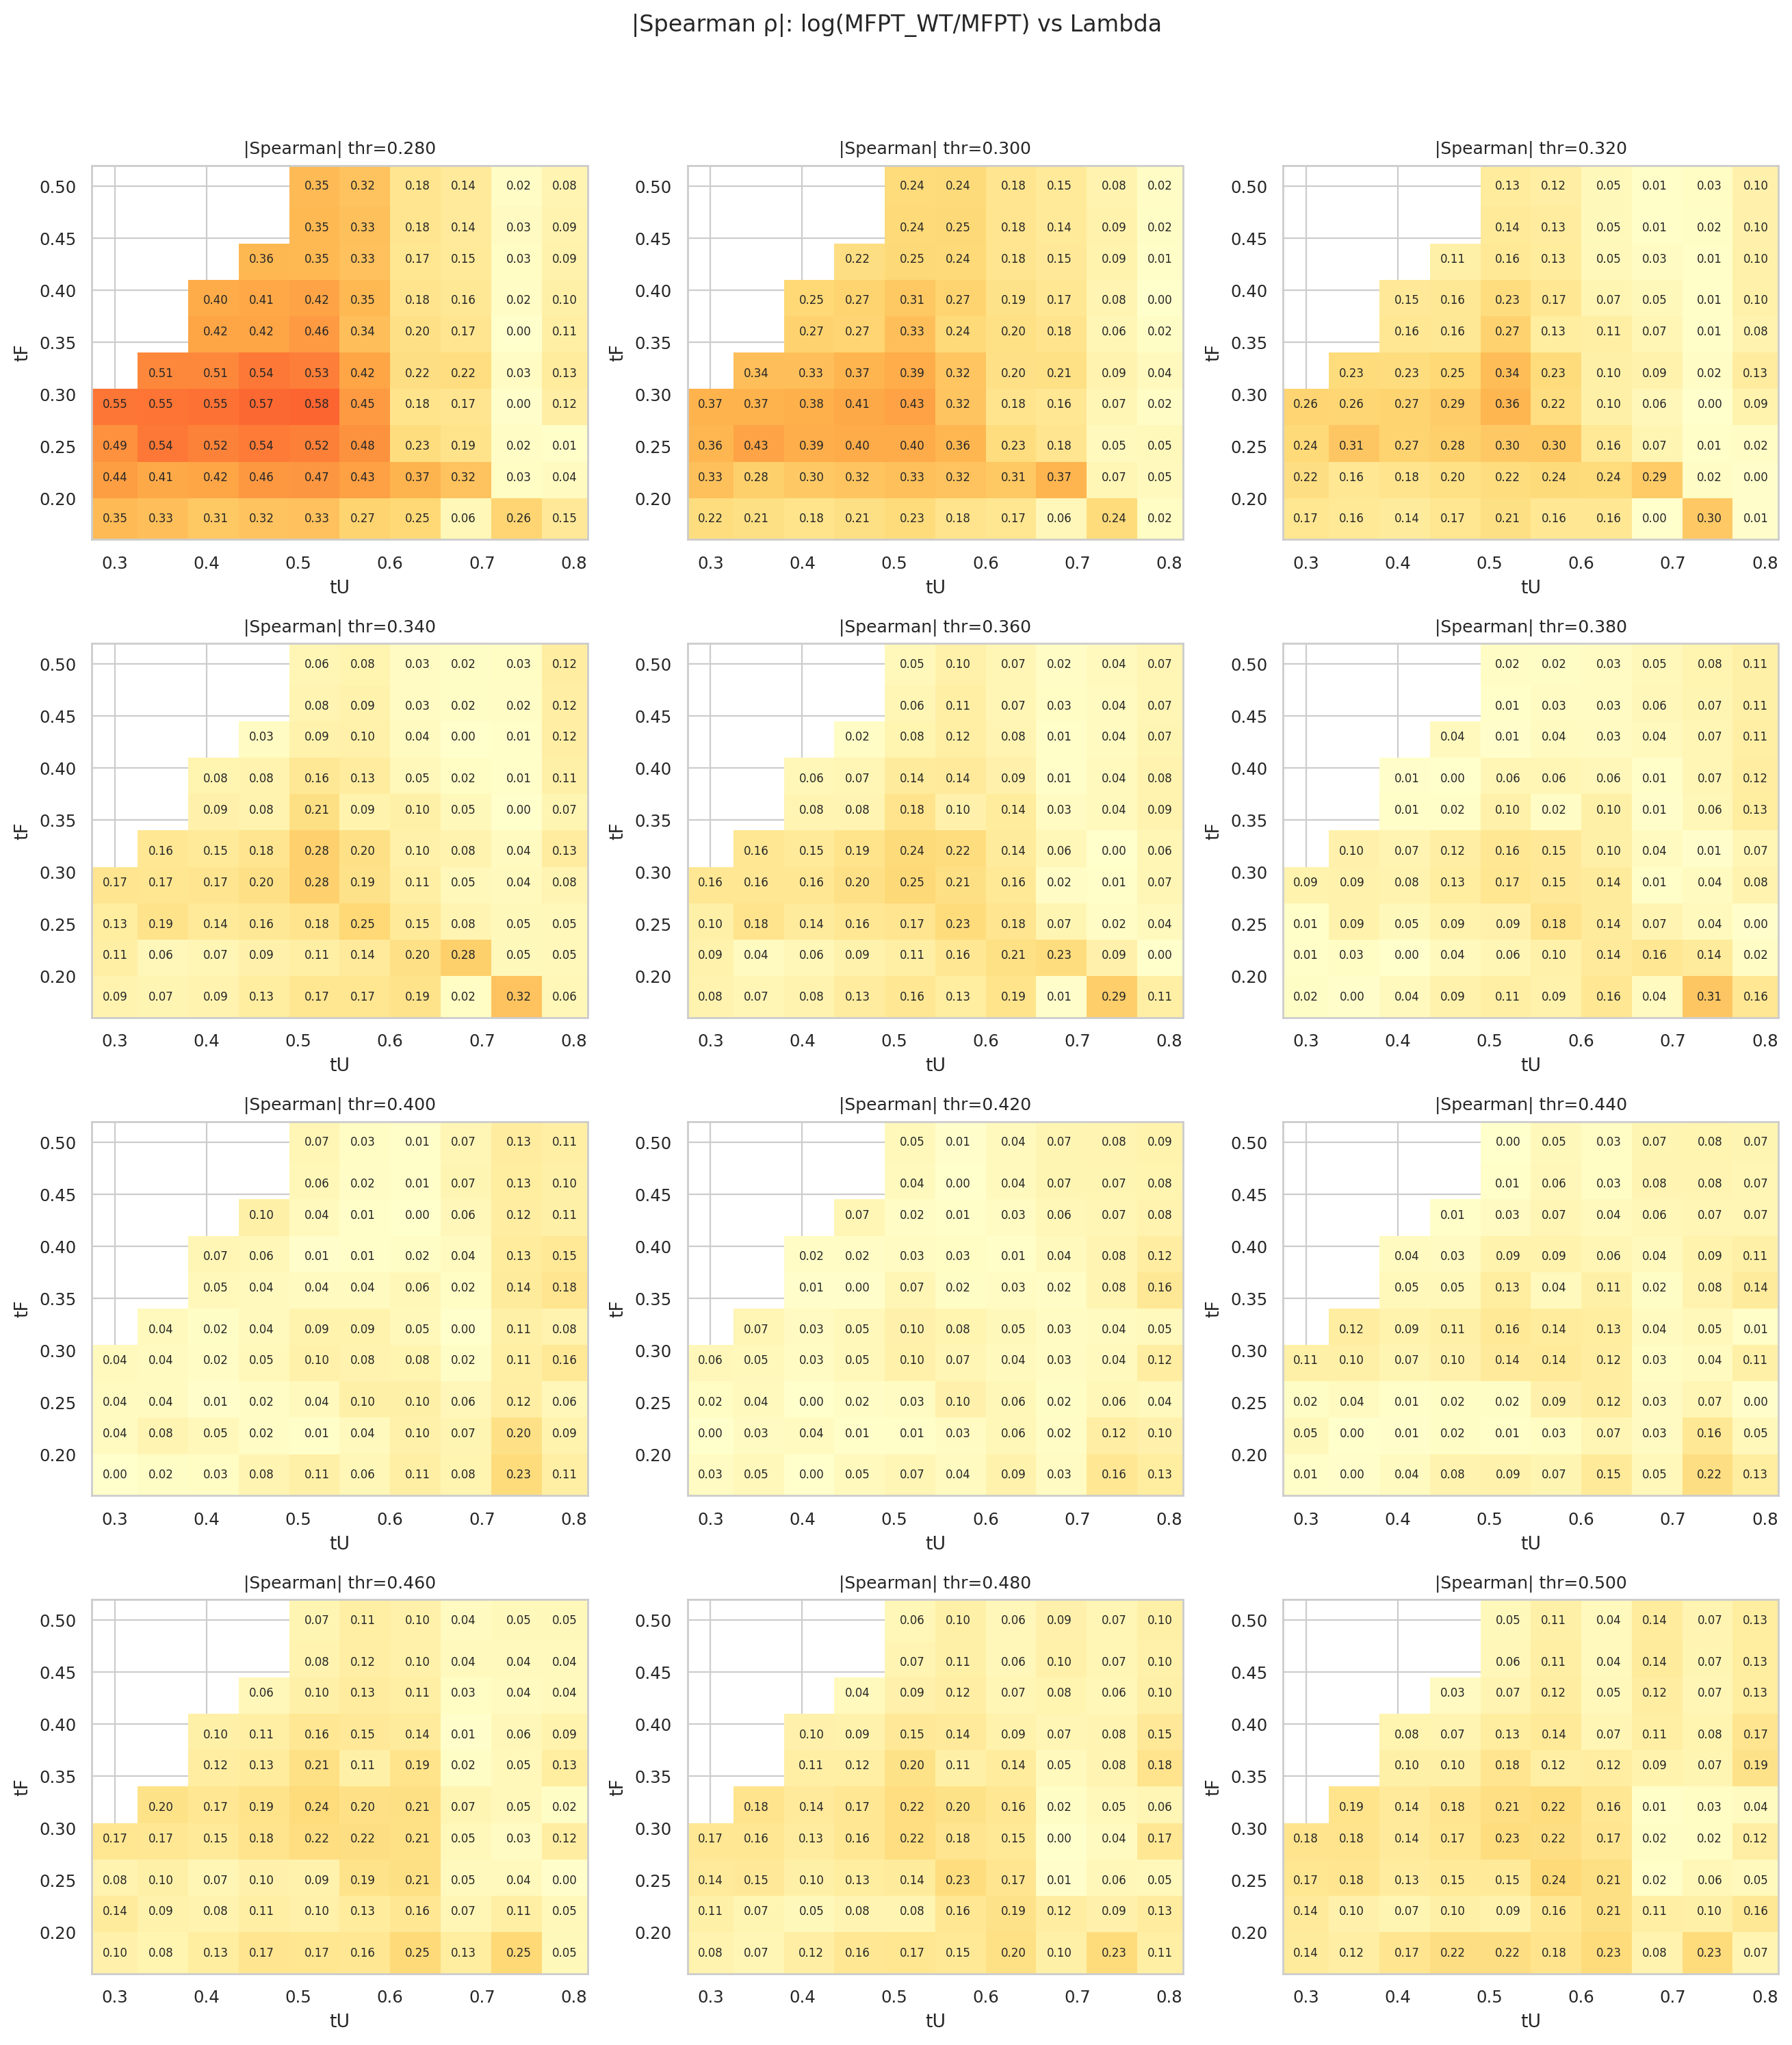

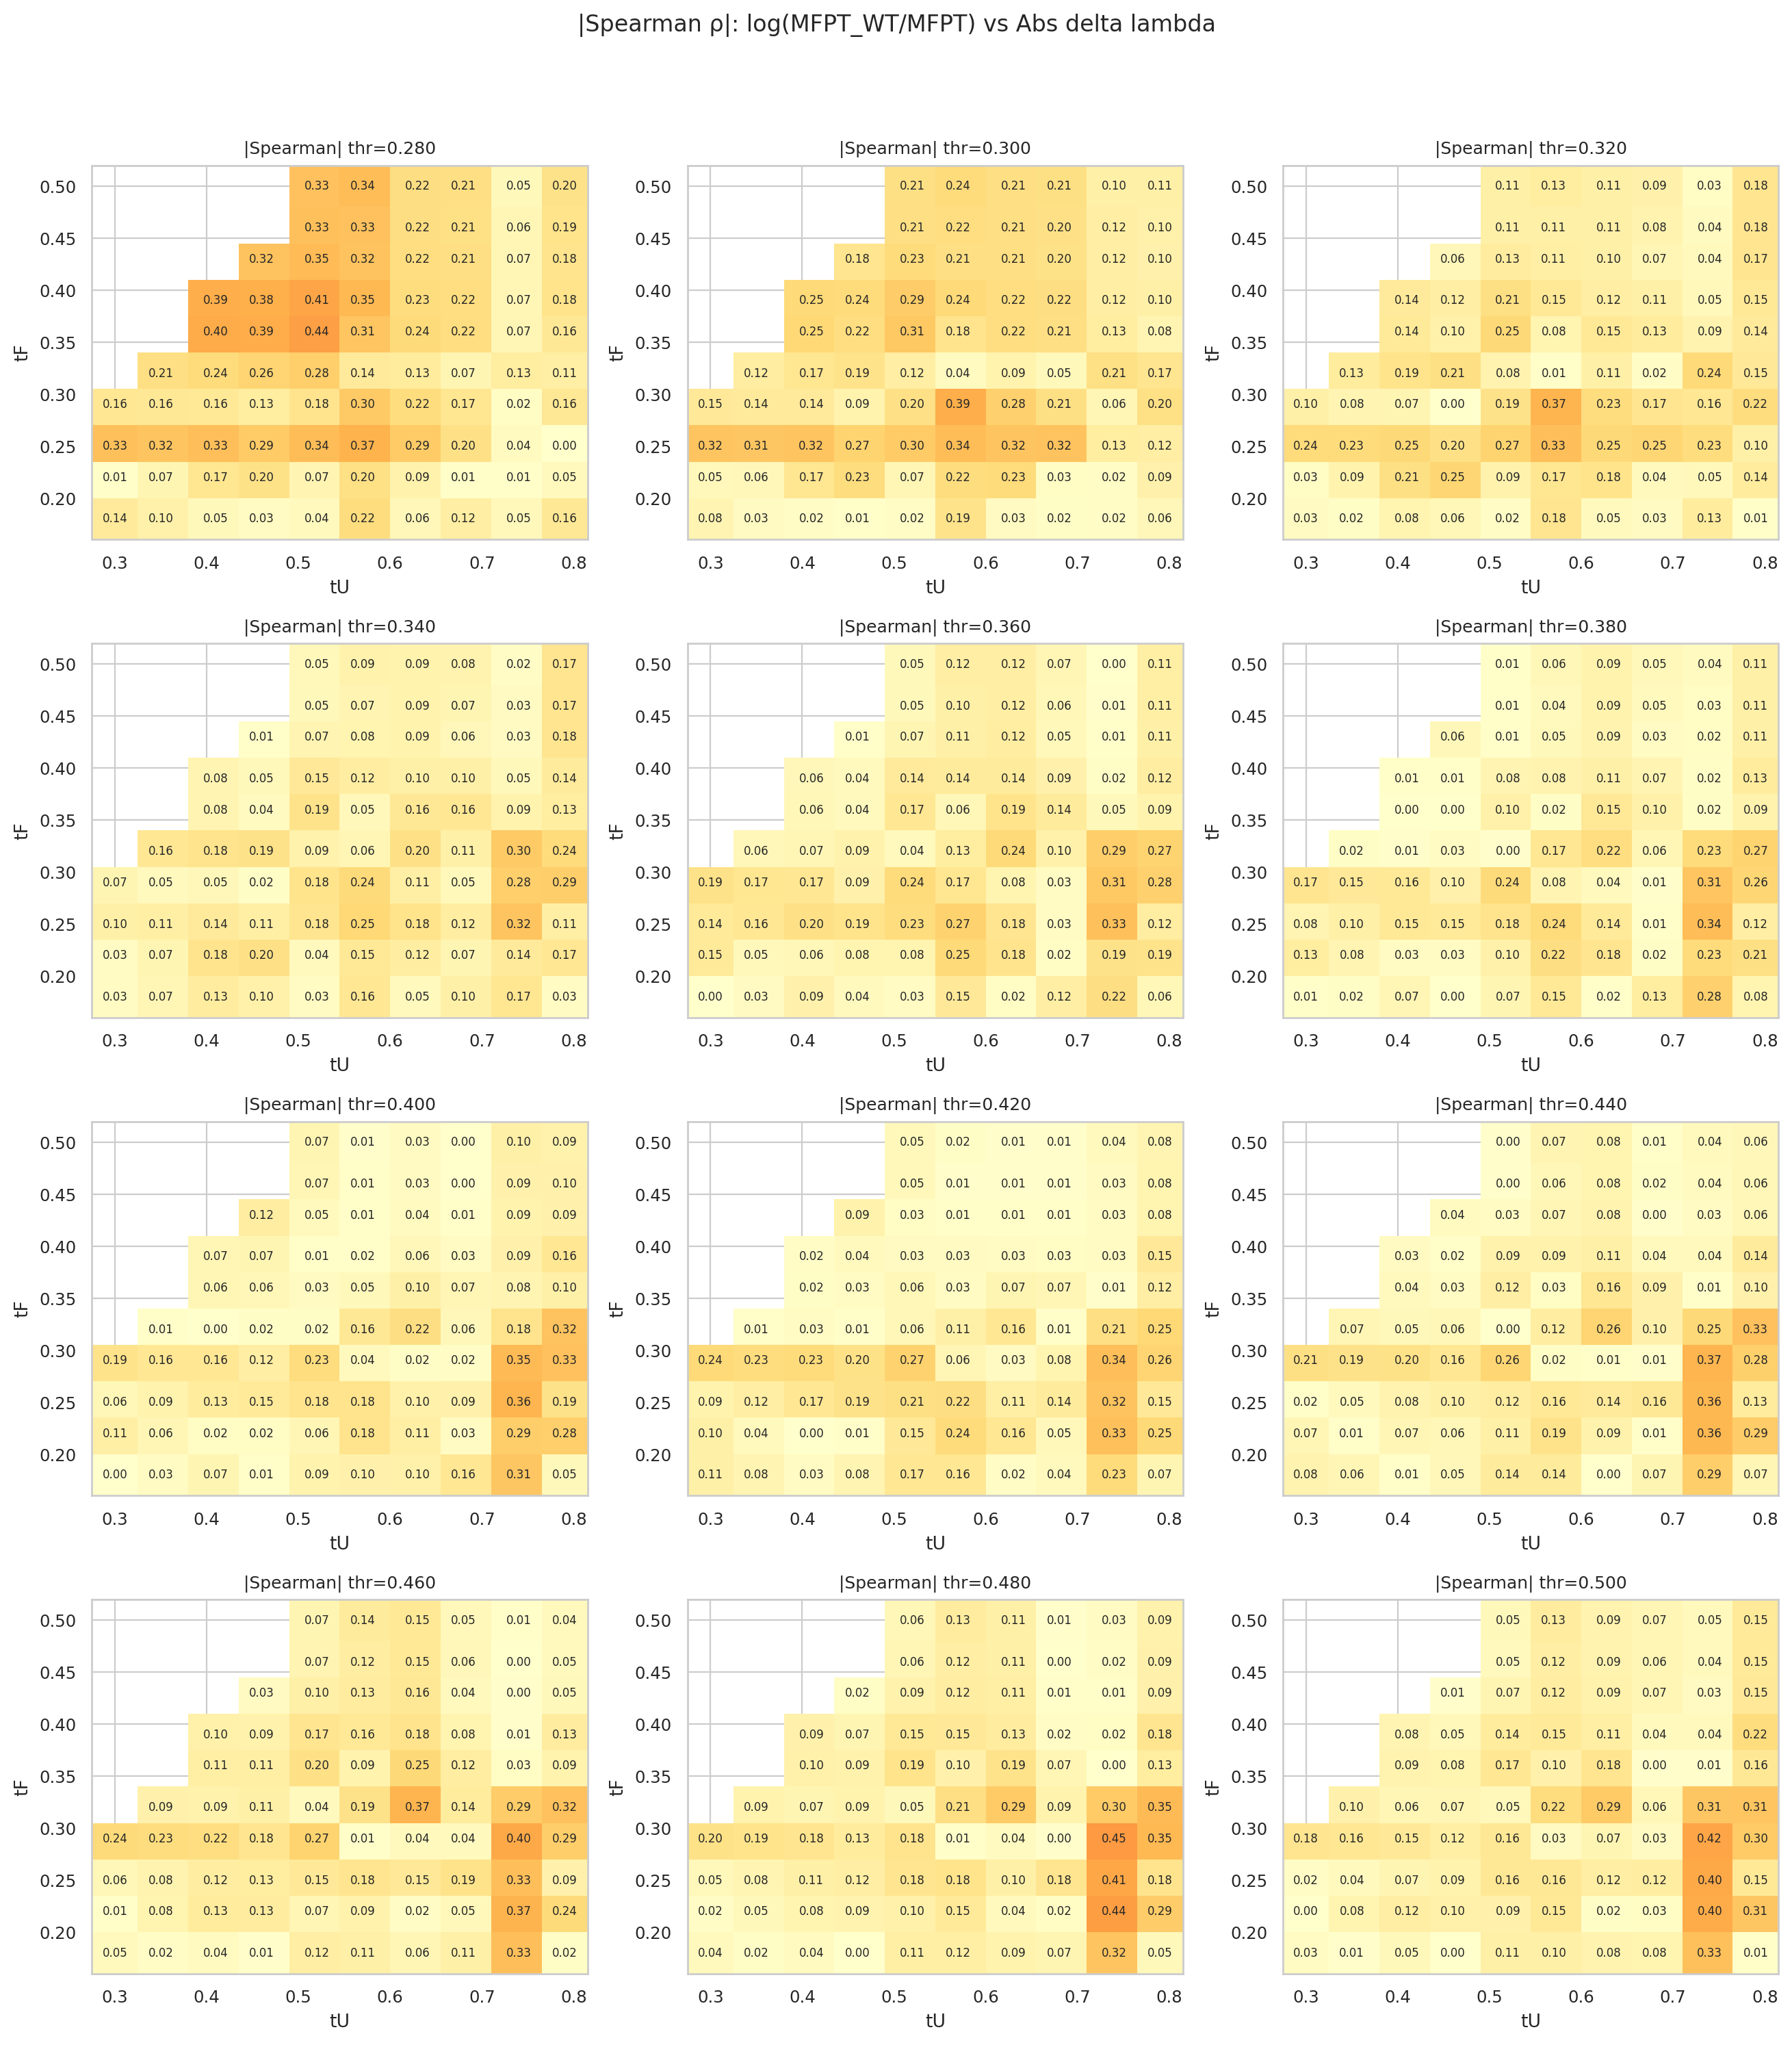

In [6]:
for metric_key, metric_label in metrics:
    results = heatmap_cache[metric_key]
    ncols = min(3, len(results) if results else 1)
    nrows = int(np.ceil(len(results) / ncols)) if results else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
    for ax, res in zip(axes.ravel(), results):
        df = pd.DataFrame(res['rows'])
        if df.empty:
            ax.axis('off')
            continue
        plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['thr']:.3f}", vmin=0, vmax=1)
    for ax in axes.ravel()[len(results):]:
        ax.axis('off')
    fig.suptitle(f"|Spearman ρ|: log(MFPT_WT/MFPT) vs {metric_label}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


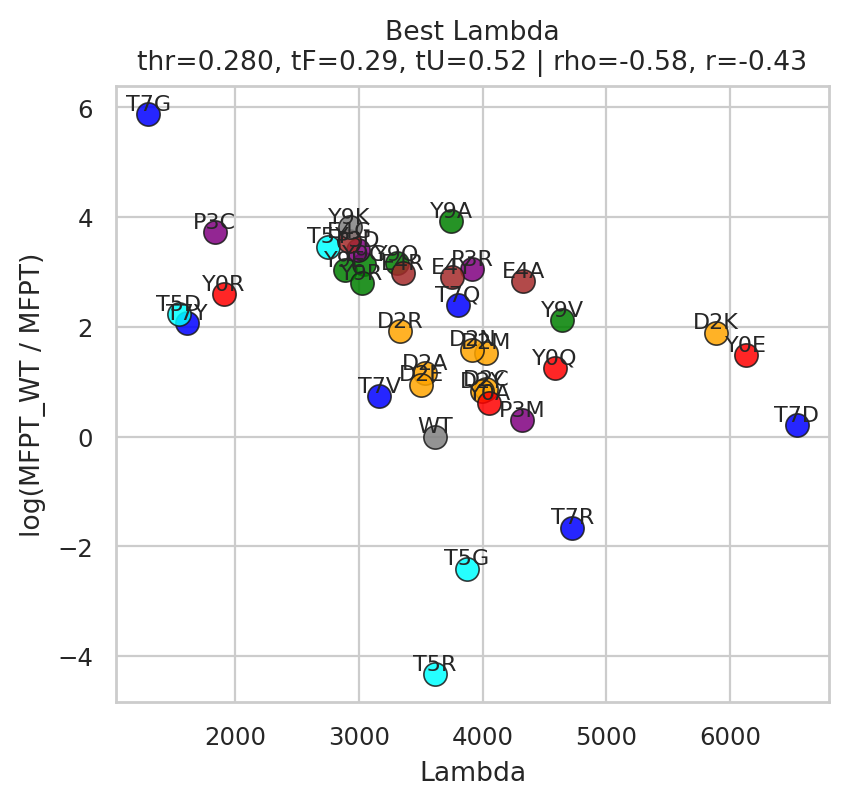

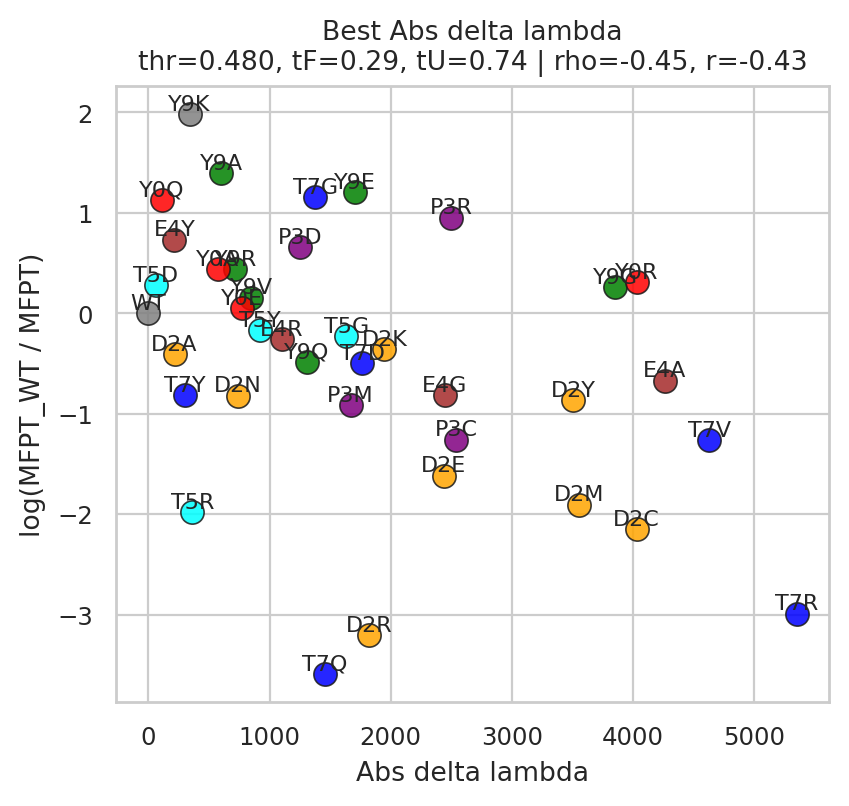

In [7]:
from common.consts import res_colors

for metric_key, metric_label in metrics:
    row = best_df.loc[best_df['metric'] == metric_key].iloc[0]
    df = best_cache[metric_key]
    fig, ax = plt.subplots(figsize=(4.6, 4.0))
    scatter_with_labels(
        ax,
        df,
        metric_key,
        'log_mfpt_ratio',
        label_col=None,
        color_col='residue_idx',
        colors=res_colors,
    )
    ax.set_xlabel(metric_label)
    ax.set_ylabel('log(MFPT_WT / MFPT)')
    ax.set_title(
        f"Best {metric_label}\n"
        f"thr={row['thr']:.3f}, tF={row['tF']:.2f}, tU={row['tU']:.2f} | "
        f"rho={row['rho']:.2f}, r={row['pear']:.2f}"
    )
    plt.show()
